# Scaling Monosemanticity — Visual Experiments

> **Goal:** Reproduce the *evaluation* ideas behind scaling SAEs to a production model: steering, specificity, feature geometry, and coverage.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Feature steering** | Does clamping one feature dominate behaviour (the Golden Gate Claude effect)? |
| 2 | **Specificity** | How do we measure whether a feature is single-concept at scale? |
| 3 | **Feature neighborhoods** | Do semantically related features sit close in feature space? |
| 4 | **Coverage scaling** | How much behaviour do features explain, and what is left as dark matter? |

---
**Linked theory:** [research/03-scaling-monosemanticity.md](../research/03-scaling-monosemanticity.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Feature steering

**Question:** The famous demo clamped Claude's 'Golden Gate Bridge' feature high, and the model brought up the bridge everywhere. Does clamping one feature direction dominate the representation regardless of input?

We treat a feature as a direction, clamp its activation high across varied inputs, and measure a 'concept detector' that reads that direction.

In [2]:
np.random.seed(1)
d, n = 24, 60
F = np.random.randn(d, n); F /= np.linalg.norm(F, axis=0)   # feature directions
gg = 7   # the 'Golden Gate' feature index

# varied inputs: random sparse mixes of features (mostly NOT the GG feature)
vals = (np.random.rand(800, n) < 0.05) * np.random.rand(800, n)
vals[:, gg] = 0
acts = vals @ F.T

# concept detector for GG = projection onto its direction
detect = lambda A: A @ F[:, gg]
normal_score = detect(acts)
steered = acts + 6.0 * F[:, gg]              # clamp the GG feature high
steered_score = detect(steered)
print(f'GG concept score  normal mean: {normal_score.mean():.2f}   steered mean: {steered_score.mean():.2f}')

GG concept score  normal mean: 0.04   steered mean: 6.04


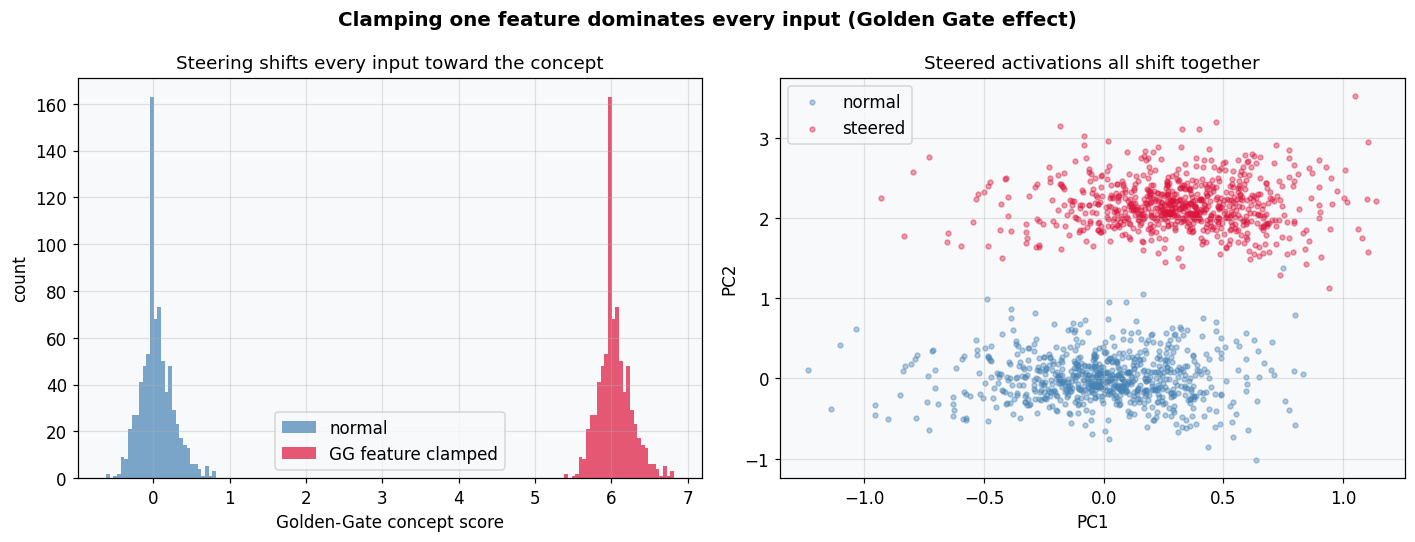

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Clamping one feature dominates every input (Golden Gate effect)', fontsize=13, fontweight='bold')

axes[0].hist(normal_score, bins=30, alpha=0.7, color='steelblue', label='normal')
axes[0].hist(steered_score, bins=30, alpha=0.7, color='crimson', label='GG feature clamped')
axes[0].set_xlabel('Golden-Gate concept score'); axes[0].set_ylabel('count')
axes[0].set_title('Steering shifts every input toward the concept')
axes[0].legend()

# 2D PCA view: all steered points pushed along the GG direction
p = PCA(2).fit(acts)
a2, s2 = p.transform(acts), p.transform(steered)
axes[1].scatter(a2[:, 0], a2[:, 1], s=10, alpha=0.4, color='steelblue', label='normal')
axes[1].scatter(s2[:, 0], s2[:, 1], s=10, alpha=0.4, color='crimson', label='steered')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('Steered activations all shift together')
axes[1].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Normally the Golden-Gate concept score is low and varied (blue); after clamping the feature, every input scores high (red), and in the PCA view all steered points shift together along the feature direction.
2. **Why it looks this way:** Adding a large multiple of the feature direction to every activation forces that concept to be present regardless of the original input — exactly the causal intervention behind 'Golden Gate Claude'.
3. **Key takeaway:** Feature steering is a clean causal test and control knob: if clamping a feature reliably changes behaviour, the feature genuinely *means* that concept.

---
## Experiment 2: Specificity

**Question:** With millions of features, we cannot inspect each by hand. How do we score whether a feature is single-concept (specific) automatically?

Specificity = the purity of a feature's *top-activating examples*. We compute it for a clean (monosemantic) feature and a mixed (polysemantic) one.

In [4]:
np.random.seed(2)
# each input has a ground-truth concept label; a feature activation per input
labels = np.random.randint(0, 6, 3000)
# clean feature: fires only for concept 3
clean = (labels == 3) * (0.5 + np.random.rand(3000)) + 0.02 * np.random.rand(3000)
# mixed feature: fires for concepts 1, 3, 5
mixed = np.isin(labels, [1, 3, 5]) * (0.5 + np.random.rand(3000)) + 0.02 * np.random.rand(3000)


def specificity(act, topk=100):
    top = np.argsort(act)[-topk:]
    lab = labels[top]
    counts = np.bincount(lab, minlength=6)
    return counts.max() / counts.sum(), counts


spec_clean, cnt_clean = specificity(clean)
spec_mixed, cnt_mixed = specificity(mixed)
print(f'specificity  clean feature: {spec_clean:.2f}   mixed feature: {spec_mixed:.2f}')

specificity  clean feature: 1.00   mixed feature: 0.37


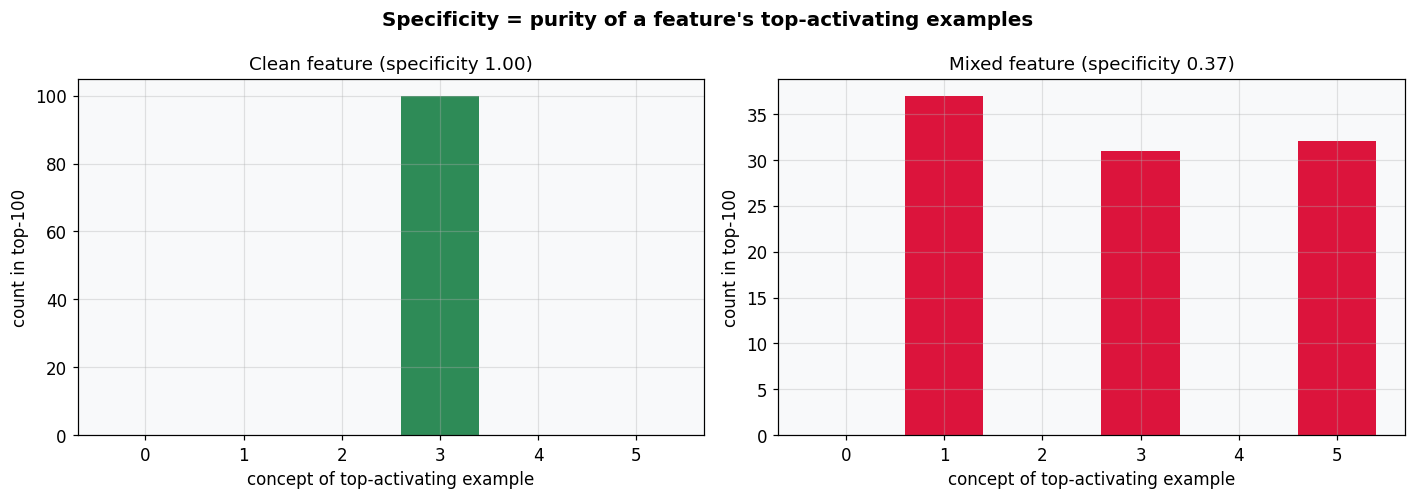

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
fig.suptitle('Specificity = purity of a feature\'s top-activating examples', fontsize=13, fontweight='bold')

axes[0].bar(range(6), cnt_clean, color='seagreen')
axes[0].set_xlabel('concept of top-activating example'); axes[0].set_ylabel('count in top-100')
axes[0].set_title(f'Clean feature (specificity {spec_clean:.2f})')

axes[1].bar(range(6), cnt_mixed, color='crimson')
axes[1].set_xlabel('concept of top-activating example'); axes[1].set_ylabel('count in top-100')
axes[1].set_title(f'Mixed feature (specificity {spec_mixed:.2f})')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The clean feature's top-100 activating examples are almost all one concept (green, specificity near 1). The mixed feature's top examples spread across three concepts (red, low specificity).
2. **Why it looks this way:** A monosemantic feature fires for exactly one concept, so its strongest activations all share that label; a polysemantic feature fires for several, so its top examples are heterogeneous.
3. **Key takeaway:** Specificity over top examples is an automatable feature-quality score — essential when a model has millions of features to triage.

---
## Experiment 3: Feature neighborhoods

**Question:** The paper finds that nearby features (by direction) tend to be semantically related — feature space has meaningful geometry. Does that show up?

We build features in semantic groups (themes) and visualize their directions plus the cosine-similarity structure.

In [6]:
np.random.seed(3)
themes = 4; per = 8; d = 32
centers = np.random.randn(themes, d)
feat, theme_id = [], []
for t in range(themes):
    for _ in range(per):
        v = centers[t] + 0.6 * np.random.randn(d)     # features in a theme are close
        feat.append(v / np.linalg.norm(v)); theme_id.append(t)
feat = np.array(feat); theme_id = np.array(theme_id)
S = feat @ feat.T                                       # cosine similarity (unit norm)
order = np.argsort(theme_id)
print(f'{themes} themes x {per} features = {len(feat)} features in {d}-D')

4 themes x 8 features = 32 features in 32-D


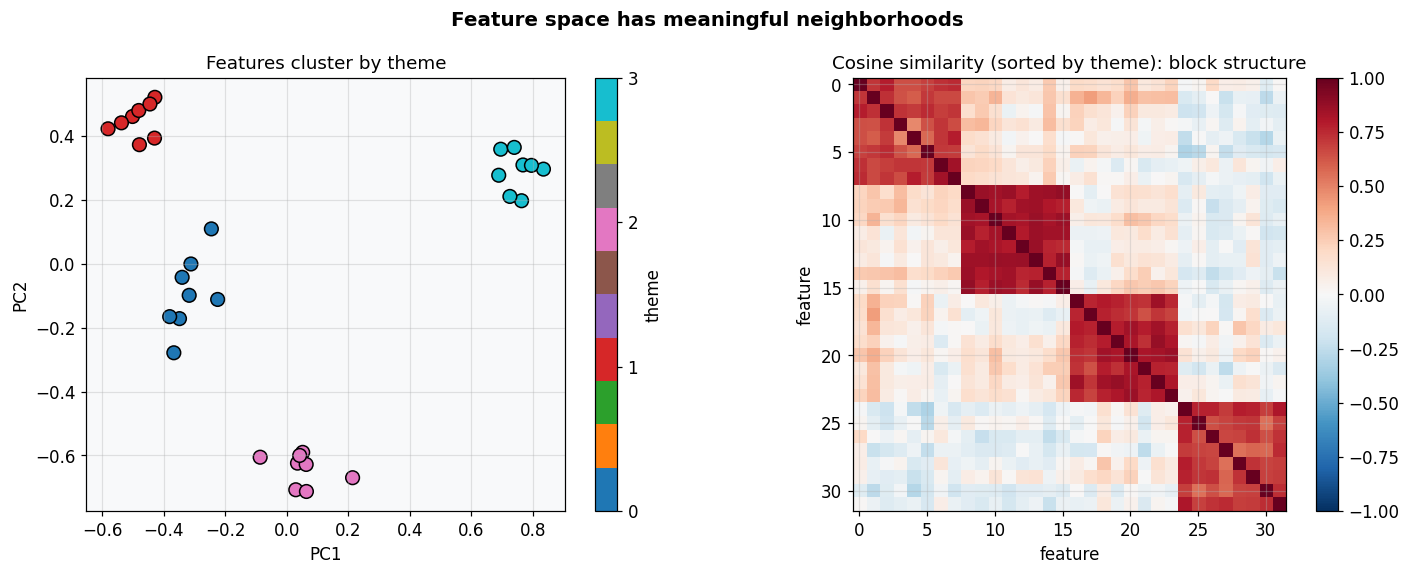

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
fig.suptitle('Feature space has meaningful neighborhoods', fontsize=13, fontweight='bold')

emb = PCA(2).fit_transform(feat)
sc = axes[0].scatter(emb[:, 0], emb[:, 1], c=theme_id, cmap='tab10', s=80, edgecolor='k')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('Features cluster by theme')
fig.colorbar(sc, ax=axes[0], label='theme', ticks=range(themes))

im = axes[1].imshow(S[order][:, order], cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('Cosine similarity (sorted by theme): block structure')
axes[1].set_xlabel('feature'); axes[1].set_ylabel('feature')
fig.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Features form clear clusters by theme in the 2D projection, and the cosine-similarity matrix (sorted by theme) shows bright blocks on the diagonal — within-theme features are similar, across-theme features are not.
2. **Why it looks this way:** Related concepts are encoded along nearby directions, so feature directions inherit the semantic structure; neighbourhoods in feature space correspond to topics.
3. **Key takeaway:** Feature geometry is interpretable — browsing a feature's neighbours surfaces related concepts, a navigation tool the paper uses across millions of features.

---
## Experiment 4: Coverage scaling

**Question:** More features explain more behaviour, but never everything — some activation remains as unexplained 'dark matter'. How does coverage grow with the number of features?

We measure how much activation variance a dictionary explains as we add more feature directions, and the residual that stays unexplained.

In [8]:
np.random.seed(4)
d, n_true = 40, 300
F = np.random.randn(d, n_true); F /= np.linalg.norm(F, axis=0)
importance = 0.97 ** np.arange(n_true)                       # feature usage decays
vals = (np.random.rand(3000, n_true) < 0.04) * np.random.rand(3000, n_true) * importance
acts = vals @ F.T
total_var = (acts ** 2).sum()

sizes = [5, 10, 20, 40, 80, 160, 300]
coverage = []
for k in sizes:
    Fk = F[:, :k]                                           # the k most-used feature directions
    proj = acts @ Fk @ np.linalg.pinv(Fk.T @ Fk) @ Fk.T     # project onto their span
    coverage.append(1 - ((acts - proj) ** 2).sum() / total_var)
print('num features:', sizes)
print('coverage    :', np.round(coverage, 3))

num features: [5, 10, 20, 40, 80, 160, 300]
coverage    : [0.349 0.588 0.852 1.    1.    1.    1.   ]


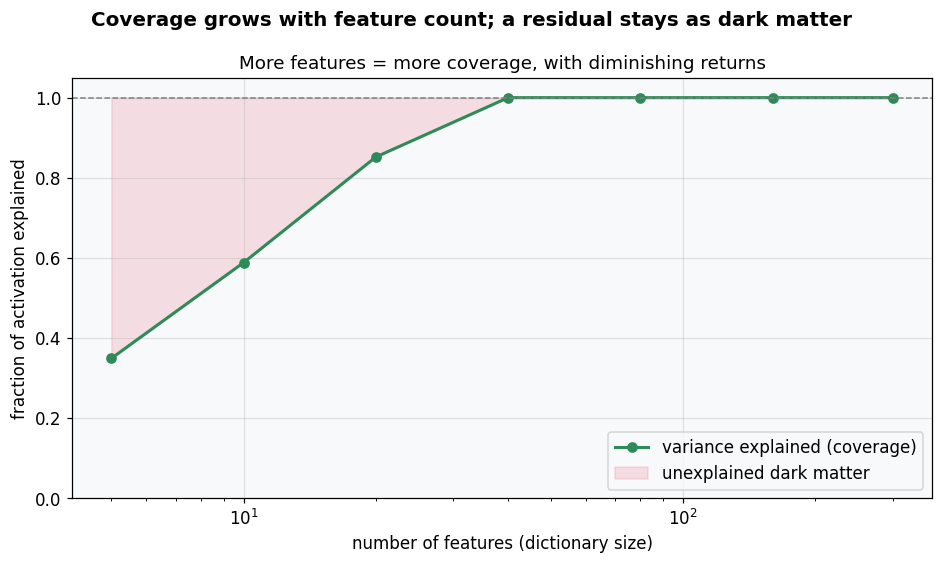

In [9]:
fig, ax = plt.subplots(figsize=(8.7, 5.2))
fig.suptitle('Coverage grows with feature count; a residual stays as dark matter', fontsize=13, fontweight='bold')

ax.plot(sizes, coverage, '-o', color='seagreen', lw=2, label='variance explained (coverage)')
ax.fill_between(sizes, coverage, 1.0, color='crimson', alpha=0.12, label='unexplained dark matter')
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('number of features (dictionary size)'); ax.set_ylabel('fraction of activation explained')
ax.set_xscale('log'); ax.set_ylim(0, 1.05)
ax.set_title('More features = more coverage, with diminishing returns')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Coverage rises steeply as the first (most-used) features are added, then flattens — the last bit of variance (red band) needs many rare features and is never fully captured at modest sizes.
2. **Why it looks this way:** A few common features explain most activation; rare features each add little, so coverage has diminishing returns. The persistent residual is the 'dark matter' the paper notes — behaviour not yet decomposed.
3. **Key takeaway:** Bigger SAEs explain more (a scaling law), but completeness is asymptotic — interpretability is never finished, only extended, which Layer A must report honestly via coverage.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Feature steering | Clamping a feature direction forces its concept into every output — a causal control knob (Golden Gate Claude). |
| 2. Specificity | Purity of top-activating examples is an automatable feature-quality score for millions of features. |
| 3. Feature neighborhoods | Related features sit close in direction space; geometry is semantically meaningful. |
| 4. Coverage scaling | More features explain more behaviour with diminishing returns; a dark-matter residual remains. |

### Connection to the broader theory

Scaling Monosemanticity takes [the SAE method](../research/02-towards-monosemanticity.md) to a production model and formalizes how to *evaluate* features — specificity, causal [steering](../../05-probing-intervention/research/09-steering-vectors.md), neighbourhoods, and coverage. These are exactly the metrics Layer A should expose. The tier now leaves the SAE line for the broader **probing classifiers survey**, then the dimensionality-reduction tools UMAP and PaCMAP.